# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

c:\Users\BongaoChristian\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\BongaoChristian\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


In [7]:

import os
import pandas as pd
import matplotlib.pyplot as plt

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

1. lead time is right skewed means booking was made close on their arrival
2. adr is right skewed meast most prices cluster at lower to moderate rate
3. high adr is peak season

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df[['lead_time', 'adr']].describe()

,lead_time,adr
count,119390.000000,119390.000000
mean,104.011416,101.831122
std,106.863097,50.535790
min,0.000000,-6.380000
25%,18.000000,69.290000
50%,69.000000,94.575000
75%,160.000000,126.000000
max,737.000000,5400.000000


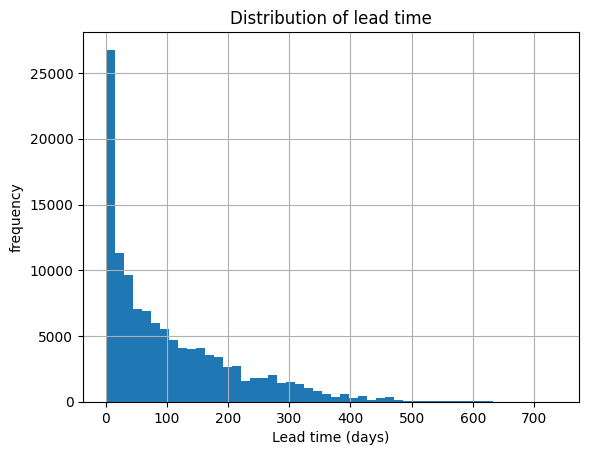

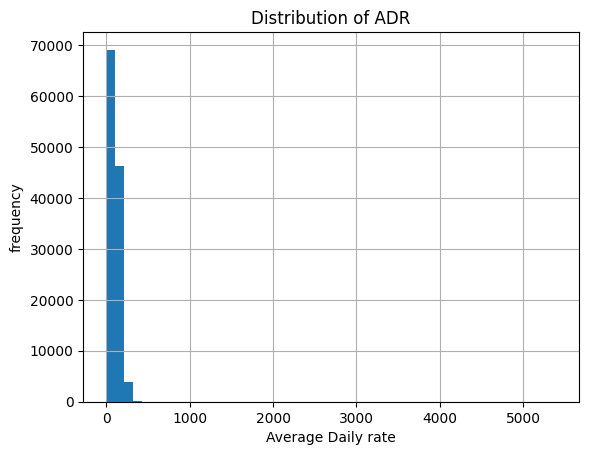

In [10]:
plt.figure()
df['lead_time'].hist(bins=50)
plt.xlabel('Lead time (days)')
plt.ylabel('frequency')
plt.title('Distribution of lead time')
plt.show()

plt.figure()
df['adr'].hist(bins=50)
plt.xlabel('Average Daily rate')
plt.ylabel('frequency')
plt.title('Distribution of ADR')
plt.show()



In [11]:
df.describe

<bound method NDFrame.describe of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



1. canceled booking have top median and wide spread in lead time
2. longer lead time are connected to high cancellation

In [12]:
# put your answer here
df.groupby('is_canceled')['lead_time'].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.848815,118.624829,0.0,48.0,113.0,214.0,629.0


<Figure size 640x480 with 0 Axes>

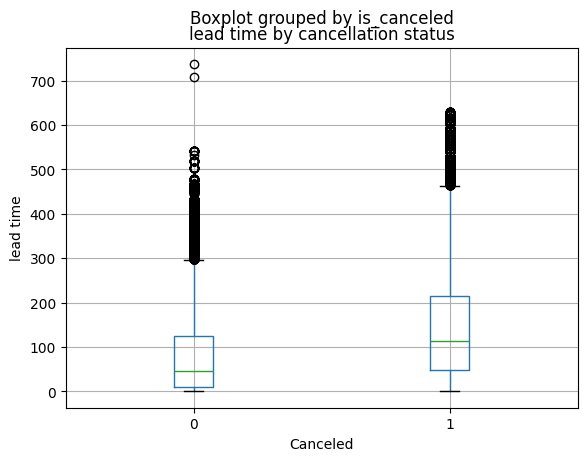

In [13]:
plt.figure()
df.boxplot(column='lead_time', by='is_canceled')
plt.xlabel('Canceled')
plt.ylabel('lead time')
plt.title('lead time by cancellation status')
plt.show()


## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

1. resort hotel shows strong seasonal higher adr during summer
2. city hotels maintain the pricing whole year

In [15]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=month_order,
    ordered=True
)


In [16]:
resort_df = df[df['hotel'] == 'Resort Hotel']
city_df   = df[df['hotel'] == 'City Hotel']


In [17]:
resort_adr = (
    resort_df.groupby('arrival_date_month')['adr']
    .mean()
    .reset_index()
)

city_adr = (
    city_df.groupby('arrival_date_month')['adr']
    .mean()
    .reset_index()
)

C:\Users\BongaoChristian\AppData\Local\Temp\ipykernel_15412\1658473444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resort_df.groupby('arrival_date_month')['adr']
C:\Users\BongaoChristian\AppData\Local\Temp\ipykernel_15412\1658473444.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_df.groupby('arrival_date_month')['adr']


In [18]:
print("Resort Hotel - Monthly ADR")
display(resort_adr)

print("\nCity Hotel - Monthly ADR")
display(city_adr)

Resort Hotel - Monthly ADR


,arrival_date_month,adr
0,January,49.461883
1,February,55.171930
2,March,57.520147
3,April,77.849496
4,May,78.758134
5,June,110.444749
6,July,155.181299
7,August,186.790574
8,September,93.252030
9,October,62.097617



City Hotel - Monthly ADR


,arrival_date_month,adr
0,January,82.628986
1,February,85.088278
2,March,92.643116
3,April,111.251838
4,May,121.638560
5,June,119.074341
6,July,110.734292
7,August,114.680455
8,September,110.004661
9,October,99.974498


## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


1. first time guess cancel frequently that repeated guest
2. repeated guest tend to shorter lead time and fewer book change

In [19]:
# put your answer here
df.groupby('is_repeated_guest')['is_canceled']
df.groupby('is_repeated_guest')[['lead_time','booking_changes']].mean()

,lead_time,booking_changes
is_repeated_guest,,
0,106.425221,0.219692
1,30.786352,0.264567


<Figure size 640x480 with 0 Axes>

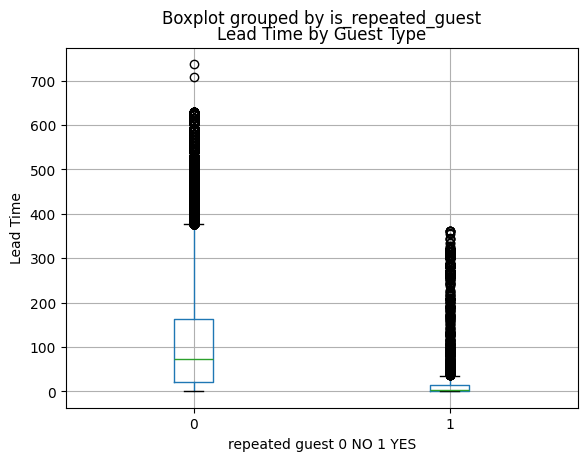

In [20]:
plt.figure()
df.boxplot(column='lead_time', by='is_repeated_guest')
plt.xlabel('repeated guest 0 NO 1 YES')
plt.ylabel('Lead Time')
plt.title('Lead Time by Guest Type')
plt.show()

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


1. guest with long lead, no deposit and non repeating guest have the highest cancellation rates
2. depost is helpful to make sure that the guest will not cancel


In [21]:
# put your answer here
df['lead_time_group'] = pd.cut(
    df['lead_time'], bins=[0,30,90,365,800], labels=['Short', 'Medium' , 'Long' , 'Very Long']
)

pattern = (
    df.groupby(['lead_time_group', 'deposit_type'])['is_canceled']
    .mean
)

pattern

C:\Users\BongaoChristian\AppData\Local\Temp\ipykernel_15412\1671624855.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['lead_time_group', 'deposit_type'])['is_canceled']


<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x000001A242927750>>

In [22]:
plt.figure()
for dep in pattern['deposit_type'].unique():
    subset = pattern[pattern['deposit_type'] == dep]
    plt.plot(subset['lead_time_group'].subset['is_canceled'], label=dep)

plt.xlabel('Lead time group')
plt.ylabel('Cancellation Rate')
plt.title('Cancenllation rate by lead time and deposit type')
plt.legend()
plt.show()

TypeError: 'method' object is not subscriptable

<Figure size 640x480 with 0 Axes>